In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
data_f = pd.read_csv('financial_data.csv')
data_p = pd.read_csv('prolongations.csv')

In [3]:
#data_f['Account'].value_counts()

In [4]:
#data_p['AM'].value_counts()

In [5]:
#data_f['id'].value_counts()

In [6]:
#data_f[data_f['id']== 958]

In [7]:
#data_p[data_p['id']== 230]

> **<h1>Приведение таблицы к нужному виду.</h1>**

Находим проекты, у которых есть 'стоп' или 'end', и удаляем их.
Некоторые проекты повторяются в таблице. Может быть так, что в одной строке с этим проектом есть искомое слово, а в другой его нет. Чтобы точно удалить из таблицы данный проект, нужно не просто найти строки (с искомыми словами), а определить id таких строк. Удаление производить уже по id.



*   находим строки, в которых встречаются значения 'стоп' или 'end'
*   выделяем в список уникальные id данных строк



In [8]:
i = data_f[(data_f == 'стоп').any(axis=1) | (data_f == 'end').any(axis=1)]['id'].unique()



*   выбираем индексы строк, где значение в столбце 'id' находится в списке i
*   удаляем строки с найденными индексами с помощью .drop()



In [9]:
data_f = data_f.drop(data_f[data_f['id'].isin(i)].index)
data_p = data_p.drop(data_p[data_p['id'].isin(i)].index)

In [10]:
data_f[(data_f == '0,00').any(axis=1)]
# ровно в одном месте значение отгрузки 0,00
# как мне кажется это то же, что "в ноль", просто почему-то по другому записали

,id,Причина дубля,Ноябрь 2022,Декабрь 2022,Январь 2023,Февраль 2023,Март 2023,Апрель 2023,Май 2023,Июнь 2023,Июль 2023,Август 2023,Сентябрь 2023,Октябрь 2023,Ноябрь 2023,Декабрь 2023,Январь 2024,Февраль 2024,Account
445,1004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"34 000,00","0,00",NaN,NaN,без А/М


In [11]:
data_f = data_f.replace('в ноль', '0.00') # заменим "в ноль" на 0

In [12]:
# убедимся, что разные сотрудники не работали над одним проектом  (иначе это бы всё усложнило)
# data_f.groupby('id').filter(lambda x: len(x['Account'].unique()) > 1)

In [13]:
# уберём столбцы 'Причина дубля' и 'Account', т. к. они в целом не нужны и будут только мешать суммированию столбцов
# Account можно удалить, т к для таблиц data_f и data_p связующим будет id
data_f = data_f.drop(['Причина дубля', 'Account'], axis=1)
# У названий месяцев в data_f и data_p разные регистры, нужно привети к одному виду (чтобы потом не возникли проблемы)
data_f.columns = data_f.columns.str.lower()

Цитата из задания:

> ‘в ноль’ <...> значит для коэффициента пролонгации нужно взять отгрузку предыдущего месяца (только если все части оплаты равны 0)"

Есть повторы id (если оплачивали по частям) и чтобы понять, что ВСЕ части оплаты равны 0, нужно их сложить (и таким образом иззбавиться от повторов).

In [14]:
pd.set_option('display.max_rows', None)
# replace(' ', '') не срабатыват, потому что это не обычный пробел а спец. символ \xa0 !!!
# поэтому надо применить replace('\xa0', '')
for col in data_f.columns[1:]:  # перебираю все столбцы кроме нулевго (id) (т е по сути перебираю столбцы с данными об отгрузке)
    data_f[col] = data_f[col].dropna().str.replace('\xa0', '').str.replace(',', '.').astype(float)  # привожу их в номальный вид и тип

# если написать data_f.groupby('id').sum(), то NaN он заменит на 0 и невозмоно будет это нули отличить от тех, что раньше были 'в ноль' (а отличать их нужно потому что последние необходимо потом заменить на отгрузку прошлого месяца)
# параметр min_count=1 говорит о том, что NaN не нужно заменять на 0, а оставить как есть
data_f = data_f.groupby('id').sum(min_count=1)
#data_f

In [15]:
# проверим что повторов больше нет

# 1 способ (сделать id из индекса обратно столбец)
data_f.reset_index(inplace=True)
data_f['id'].value_counts()

# 2 способ (обратиться к индексу)
#data_f.index.value_counts()


# После группировки по столбцу и применения агрегатной функции (такой как .sum()) исходный столбец становится индексом нового DataFrame.
# Чтобы продолжить работу с ним как с обычными данными, нужно либо восстановить индекс в столбец, либо обратиться к самому индексу напрямую.

,count
id,
1015,1
15,1
16,1
958,1
956,1
955,1
954,1
951,1
947,1


Теперь (как и требовалось по условию задачи) нужно заменить нулевые отгрузки на значение отгрузки предыдущего месяца (если отгрузка есть, иначе оставить 0.00).


In [16]:
#data_f[data_f.isna().any(axis=1)] # выбирает строки, содержащие хотя бы одно пропущенное значение.
# так тоже работает data_f[data_f.isin([np.nan]).any(axis=1)]

for index, row in data_f.iterrows():
    for column_name, cell_value in list(row.items())[1:]: # пропускаю первый столбец id # если бы id не был столбцом (т е после gropby я не сделала его из индекса опять столбцом, то из list()[1:] нужно было бы оставить только то что в () )
        if column_name != 'ноябрь 2022' and cell_value == 0 and not pd.isna(v): # а через numpy так: not np.isnan(v) # не беру столбец Ноябрь 2022 т к в таблице для ннё нет "предыдущего месяца"
            #print(f"В ячейке ({index}, {column_name}) содержится 0 который надо заменить на значение предыдущего месяца (v)")
            data_f.at[index, column_name] = v
        v = cell_value

> **<h1>Подготовка шаблона итоговой таблицы (пока с нулевыми коэффициентами).</h1>**

Было принято решение сделать одну,что будет хранить в себе всю необходимую информацию. Может показаться, что эта таблица большая и громоздкая, её сложно читать. Но используя только её можно сделать любую визуализацию, что кажется довольно удобным.

In [17]:
manager = pd.DataFrame(data_p['AM'].unique(), columns=['Менеджер'])

# 1 способ (чтобы добавить новую строку в конец manager)
manager.loc[len(manager)] = ['Весь отдел'] #len(manager)  - так указываем индекс, куда надо вставить новую строку (в данном случае в самый конец)

# 2 способ
#new_manager = pd.Series(['Весь отдел'], index=['Менеджер'])
#manager = manager.append(new_manager, ignore_index=True)

coefficient = pd.DataFrame({'Тип коэфф.': ['коэфф_1', 'коэфф_2']})
data_res = manager.merge(coefficient, how='cross')

In [18]:
# если бы надо было брать все столбцы кроме id: data_f.columns.drop(['id']) или вместо drop(['id'] можно было ещё использовать difference(['id']), но он добавляет столбцы в произвольном порядке
# тут же надо брать только месяцы 2023 года, т е опустить столбцы 'id', 'Ноябрь 2022', 'Декабрь 2022', 'Январь 2024', 'Февраль 2024' (по сути первые 3 и последние 2)
# [3:15] = [3:-2]
for col in data_f.columns[3:15]:
    data_res[col.replace(' 2023', '')] = 0.00  # удаляю подпиь года ' 2023' в заголовках, чтобы на графиках не занимали место напрасно
data_res['год'] = 0.00
#data_res

> **<h1>Вычисление коэффициентов и заполнение таблицы.</h1>**

In [19]:
def counting_prolongations(name, month):


    # data_f.columns.get_loc(month) возвращает индекс (номер) столбца с указанным именем
    # data_f.columns[7] а так можно наоборот получить название по номеру
    previous_month = data_f.columns[data_f.columns.get_loc(month) - 1]
    previous_month_2 = data_f.columns[data_f.columns.get_loc(month) - 2]


    '''вычисление первого коэффициента пролонгации (Для проектов, пролонгированных в первый месяц)'''


    # id проектов, завершившихся в прошлом месяце (previous_month)
    if name == 'Весь отдел':
        ids = data_p[(data_p['month'] == previous_month)]['id'].unique()  # .isin([name]) - проверяет есть ли в столбце хотб какой-то элемент из списка name (т к я поместила его в [] он вместо str воспринимается как список) #в итоге получаем список с нужными id (которые к тому же не повторяются). Пример [848 891 904 274]
    else:
        ids = data_p[(data_p['AM'] == name) & (data_p['month'] == previous_month)]['id'].unique()  # .isin([name]) - проверяет есть ли в столбце хотб какой-то элемент из списка name (т к я поместила его в [] он вместо str воспринимается как список) #в итоге получаем список с нужными id (которые к тому же не повторяются). Пример [848 891 904 274]

    # сумма отгрузки этих проектов за прошлый месяц (previous_month)
    b = sum(data_f[data_f['id'] == id][previous_month].sum() for id in ids) # в .sum() нет смысла (ведь в data_f id не повторяются и суммировать там нечего), но если например применить вместо него .item() то в результате получается nan, если ничего не применять тоже не то... Поэтому здесь это не для суммы а скорее для корректной обработки данных

    # сумма отгрузки проектов (за month), пролонгированных в первый месяц после завершения (month)
    a = sum(data_f[data_f['id'] == id][month].sum() for id in ids)

    coeff_1 = a/b if b != 0 else 0 # т к  на 0 делить нельзя то если b=0 то и coeff_1=0


    '''вычисление второго коэффициента пролонгации (Для проектов, пролонгированных во второй месяц)'''


    # id проектов, завершившихся в позапрошлом месяце (previous_month_2)
    if name == 'Весь отдел':
        ids = data_p[(data_p['month'] == previous_month_2)]['id'].unique()
    else:
        ids = data_p[(data_p['AM'] == name) & (data_p['month'] == previous_month_2)]['id'].unique()

    # оставляем только те id, у которых сумма отгрузки в прошлом месяце (previous_month) равна 0 (т е они не пролонгированы в первый месяц посла завершения)
    ids = [id for id in ids if data_f[data_f['id'] == id][previous_month].sum() == 0]   # вот так в ids можно оставить только те id, которые > 123: ids = [id for id in ids if id > 123]

    # сумма отгрузки этих проектов за позапрошлый месяц (previous_month_2) (те в месяц завершения проекта)
    b = sum(data_f[data_f['id'] == id][previous_month_2].sum() for id in ids)

    # сумма отгрузки проектов (за month), пролонгированных во второй месяц после завершения (month)
    a = sum(data_f[data_f['id'] == id][month].sum() for id in ids)

    coeff_2 = a/b if b != 0 else 0

    return coeff_1, coeff_2

*   <h3>Вычисление коэффициентов за каждый месяц.</h3>

In [20]:
# index чётные - коэфф_1, не чётные - коэфф_2
for index, row in data_res.iterrows():
    name = data_res.at[index, 'Менеджер'] # беру конкретного сотрудника
    for column_name, cell_value in list(row.items())[2:-1]: # перебираю месяцы (столбцы начиная со 2-го и исключая последний (весь год)) и вычисляю коэфф.
        #print(f"В ячейке ({index}, {column_name}) хранится значение {cell_value}")
        if index % 2 == 0: # беру только чётные индексы (ведь ф-я за раз считает оба коэфф. поэтому считать одно и то же дважды нет смысла)
            data_res.at[index, column_name], data_res.at[(index+1), column_name] = counting_prolongations(name, column_name+' 2023') # функция возвращает сразу 2 коэффициента, каждый из них записываю в нужную ячейку


*   <h3>Вычисление коэффициентов за год</h3>


In [21]:
# Не совсем понятно как это сделать, поэтому просто пойдём по пути наименьшего сопротивления и посчитаем среднее арифметическое.
for index, row in data_res.iterrows():
    data_res.at[index, 'год'] = row.iloc[2:-1].mean()


In [22]:
data_res

,Менеджер,Тип коэфф.,январь,февраль,март,апрель,май,июнь,июль,август,сентябрь,октябрь,ноябрь,декабрь,год
0,Васильев Артем Александрович,коэфф_1,0.598171,1.056563,0.627250,0.191745,0.318410,0.389287,0.585016,0.477504,0.172433,0.886750,0.621001,0.324063,0.520683
1,Васильев Артем Александрович,коэфф_2,0.000000,0.054581,0.707823,0.110203,0.000000,0.056963,0.000000,0.000000,0.000000,0.072256,0.000000,0.484859,0.123890
2,Михайлов Андрей Сергеевич,коэфф_1,0.687923,0.903645,2.430577,1.098839,1.189616,0.000000,1.197525,0.000000,0.000000,0.449078,0.000000,0.000000,0.663100
3,Михайлов Андрей Сергеевич,коэфф_2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,Соколова Анастасия Викторовна,коэфф_1,0.400820,0.276900,0.920991,1.065835,0.195342,0.766422,0.622542,0.541263,0.260156,0.815176,0.270591,0.791061,0.577258
5,Соколова Анастасия Викторовна,коэфф_2,0.678847,0.215676,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.074544
6,Иванова Мария Сергеевна,коэфф_1,0.270066,0.000000,0.446074,0.277683,1.000000,0.000000,0.472611,0.540675,1.000000,0.000000,0.000000,0.000000,0.333926
7,Иванова Мария Сергеевна,коэфф_2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
8,Попова Екатерина Николаевна,коэфф_1,0.440678,0.000000,0.496262,0.166305,0.605139,0.000000,0.089105,0.479936,0.747004,0.700165,0.000000,0.000000,0.310383
9,Попова Екатерина Николаевна,коэфф_2,0.000000,0.000000,0.000000,0.190907,0.000000,0.000000,0.505786,0.000000,0.000000,0.000000,0.189837,0.000000,0.073877


<h4>Таблица готова. Сохраняем её в Excel.</h4>

In [23]:
#data_res.to_csv('result_analis.csv', index=False, encoding='utf-8')
data_res.to_excel('result_analis.xlsx', index=False)


> **<h1>Визуализация данных.</h1>**

Построим тепловую карту (для каждого типа коэффициента отдельно).

In [24]:
plt.rcParams['figure.figsize'] = (8, 5)

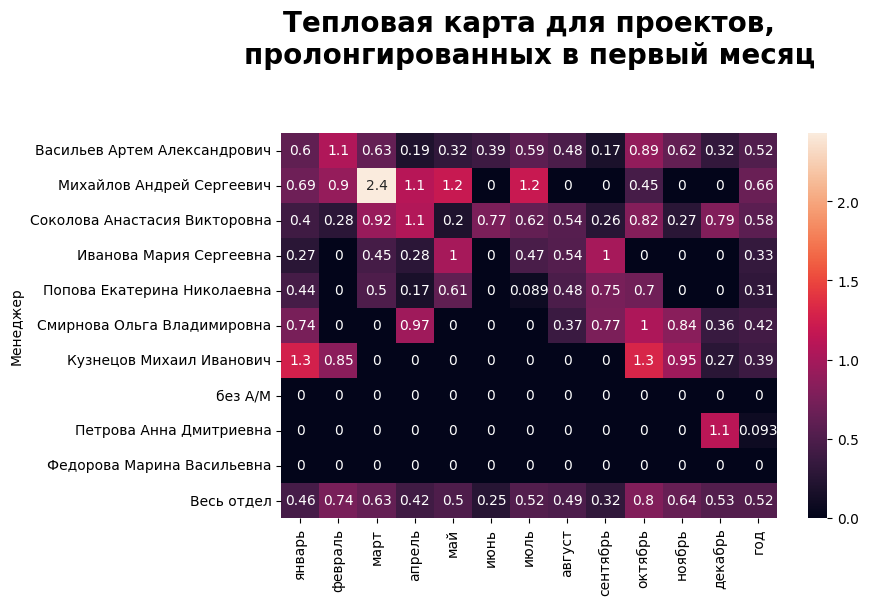

In [25]:
sns.heatmap(data_res[data_res['Тип коэфф.'] == 'коэфф_1'].drop('Тип коэфф.', axis=1).set_index('Менеджер'), annot=True)
plt.title("Тепловая карта для проектов,\nпролонгированных в первый месяц", fontweight='bold', fontsize=20, pad=50)
plt.show()

# Чтобы заголовок автоматически переносился на следующую строку при превышении определенной длины, можно воспользоваться методом wrap_text() из библиотеки matplotlib.text.
# Но гораздо проще и удобнее разделить заголовок вручную с помощью переноса строки (\n) внутри самого текста.

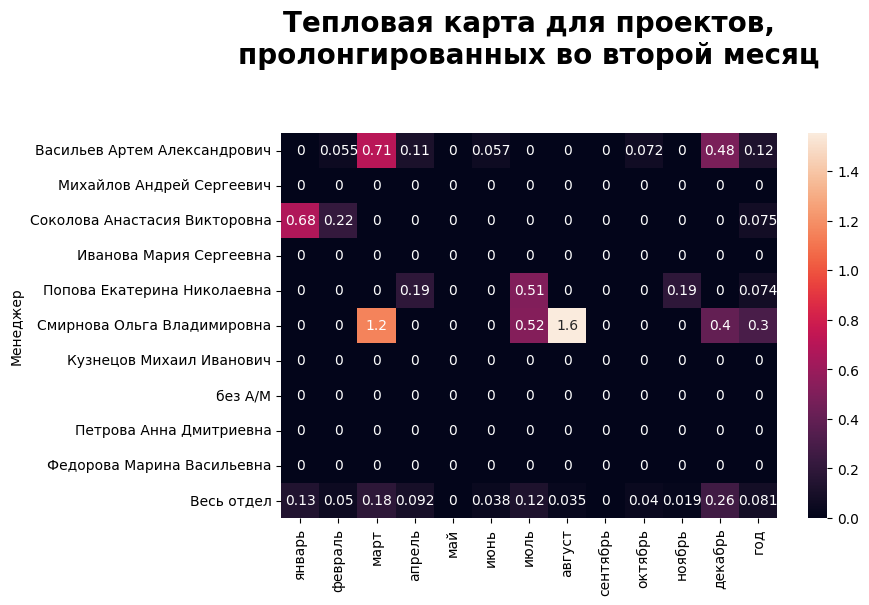

In [26]:
sns.heatmap(data_res[data_res['Тип коэфф.'] == 'коэфф_2'].drop('Тип коэфф.', axis=1).set_index('Менеджер'), annot=True)
plt.title("Тепловая карта для проектов,\nпролонгированных во второй месяц", fontweight='bold', fontsize=20, pad=50)
plt.show()

Отобразим в виде столбчатой диаграммы месячные показатели (для каждого сотрудника и для всего отдела).



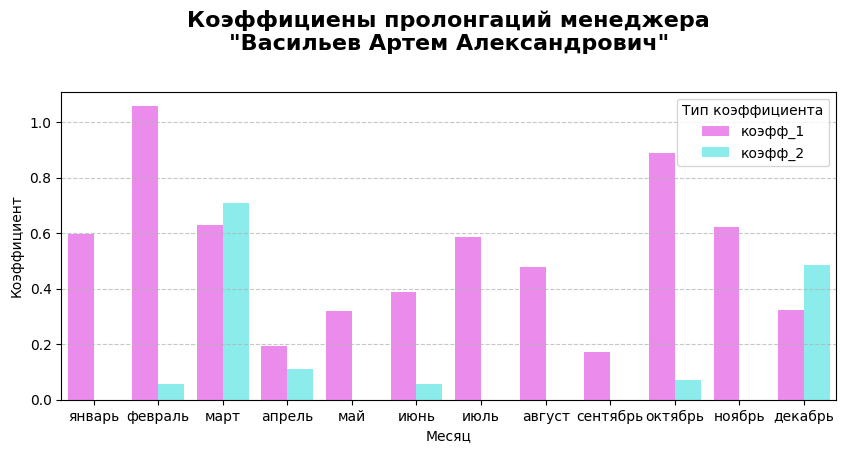

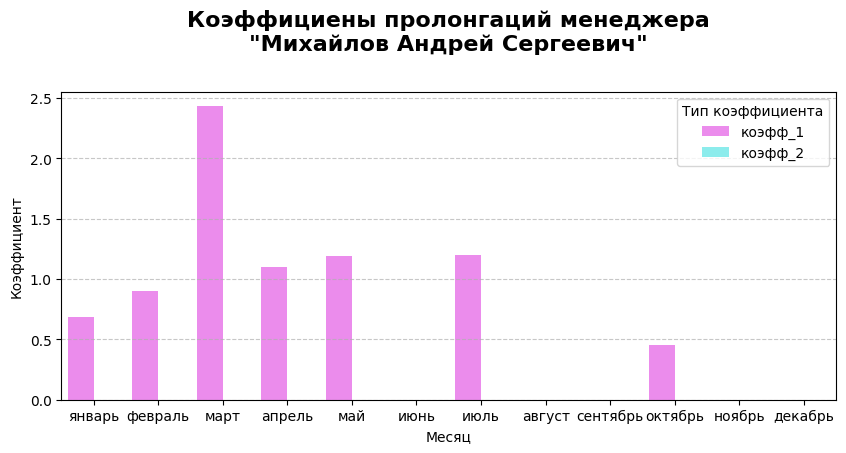

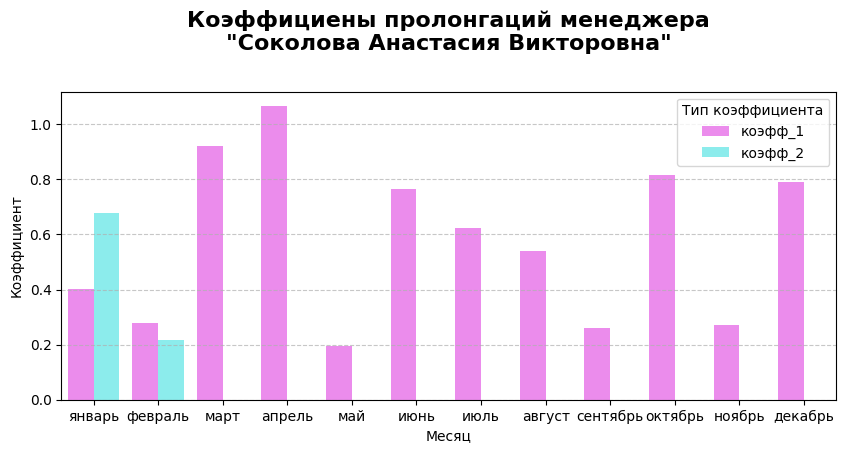

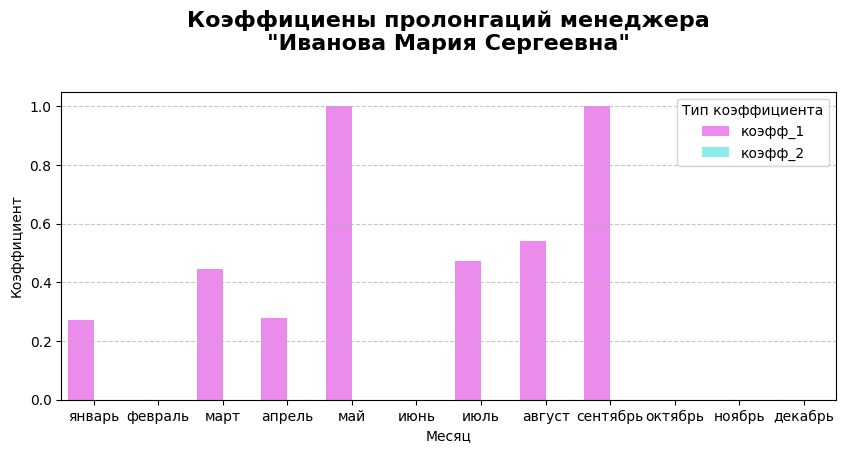

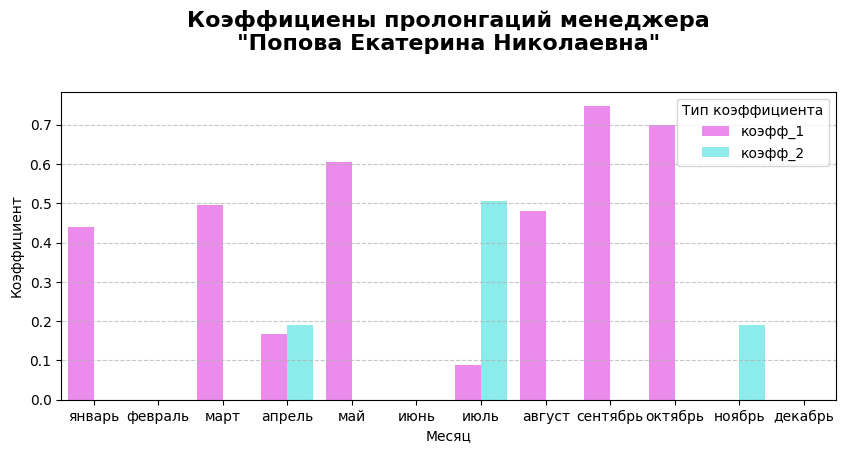

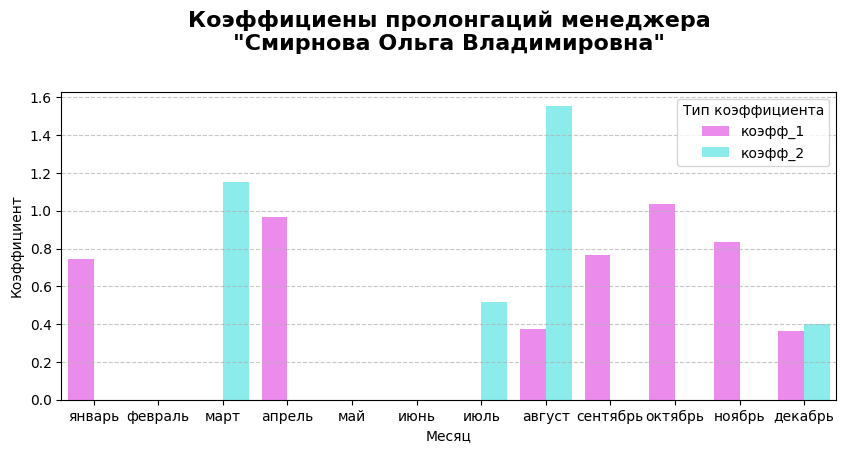

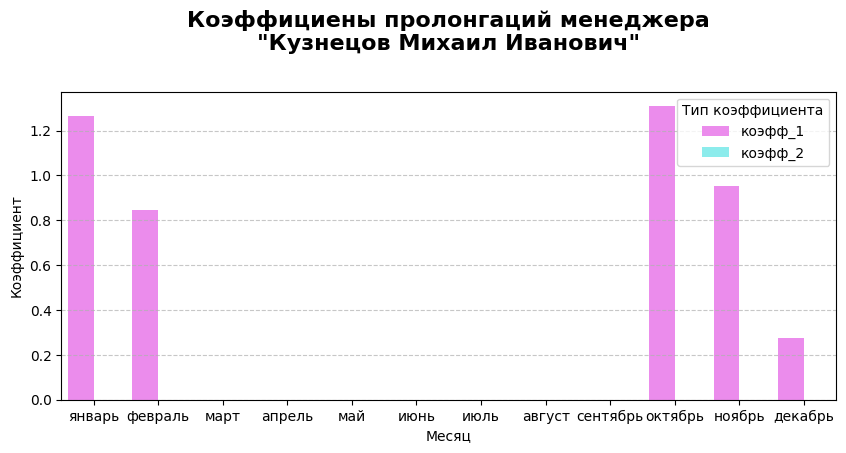

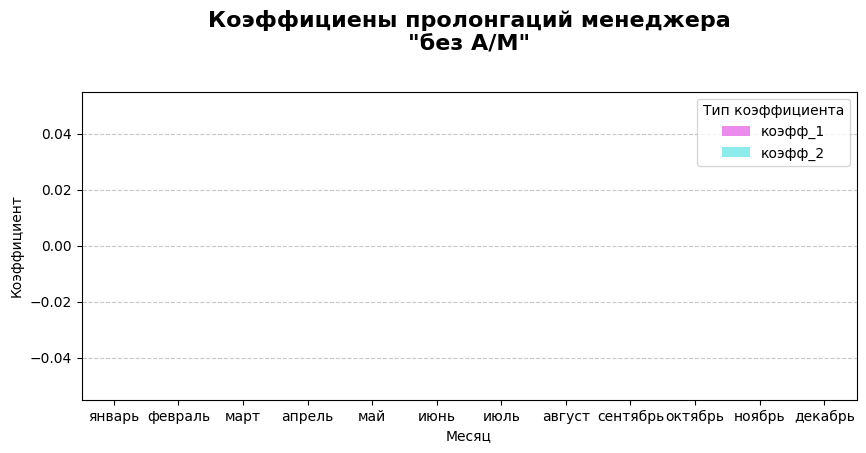

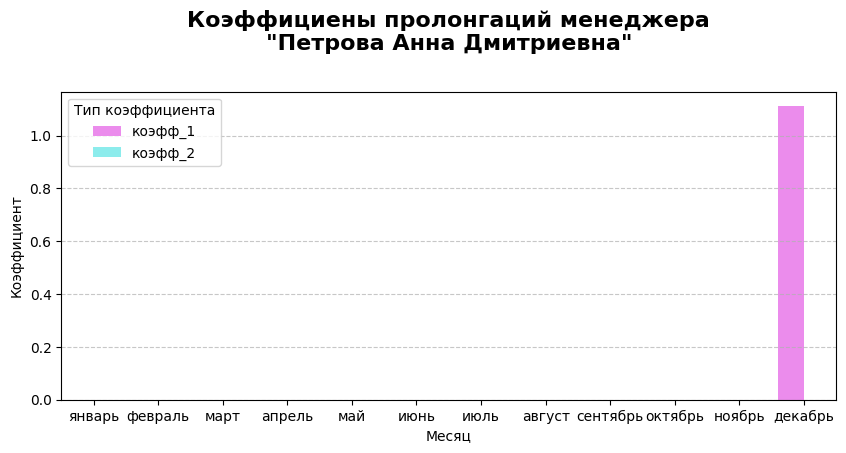

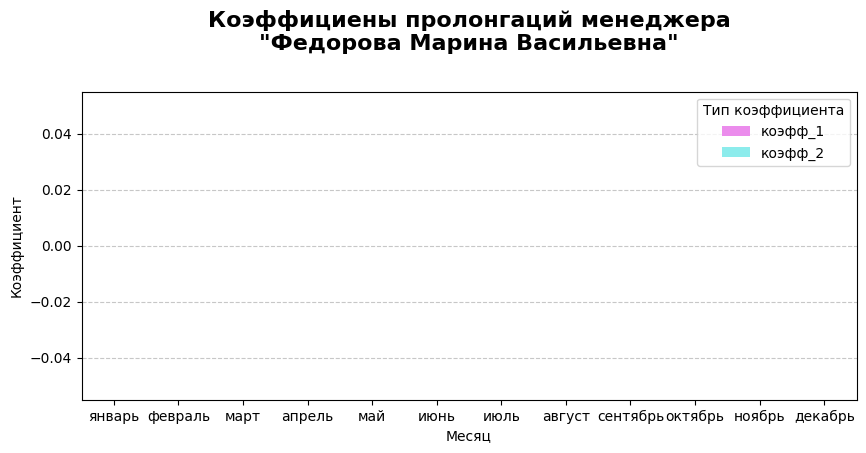

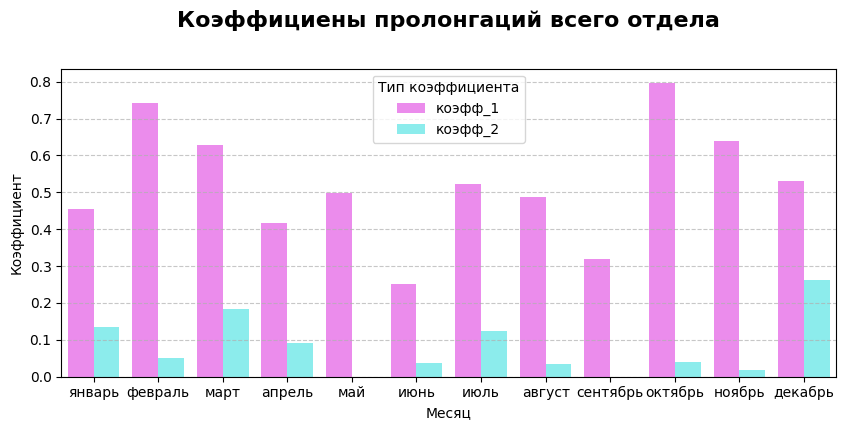

In [27]:
# Приводим данные к форме, удобной для рисования
melted_df = data_res.melt(id_vars=['Менеджер', 'Тип коэфф.'], var_name='Месяц', value_name='Коэффициент')
# т е теперь вместо того, чтобы хранить каждый месяц в отдельном столбце, они все хранятся в столбце 'месяц'
# по итогу каждый менеджер появляется в таблице 12*2=24 раза (в сочетании каждый тип с каждым месяцем)

# Построение графика

# hue='Тип коэфф.' чтобы цвет зависел от типа
# ci=None чтобы не было "доверительных линий" посередине столбцов, но программа поругалась, сказала лучше используй это: errorbar=None
# можно было не замарачиваться с оттенками в hex и просто написать palette=["b", "g"]
# перебираю всех менеджеров и для каждого рисую отдельную диаграмму (причём значения за год не трогаю, решила их в отдельный график вынести)
for man in data_res['Менеджер'].unique():
    plt.figure(figsize=(10, 4))
    sns.barplot(x='Месяц', y='Коэффициент', hue='Тип коэфф.', data=melted_df[(melted_df['Менеджер'] == man) & (melted_df['Месяц'] != 'год')], errorbar=None, palette=["#fa7cfc", "#7cfcfc"])

    # Заголовок и оформление
    plt.title(f'Коэффициены пролонгаций менеджера\n"{man}"', fontweight='bold', fontsize=16, pad=30) if man != 'Весь отдел' else plt.title(f'Коэффициены пролонгаций всего отдела', fontweight='bold', fontsize=16, pad=30)
    plt.grid(axis='y', linestyle='--', alpha=0.7)  # Установка сетки (горизонтальные линии)
    plt.legend(title='Тип коэффициента')

    plt.show()


Отобразим в виде линейной диаграммы годовые показатели (для каждого сотрудника и для всего отдела).

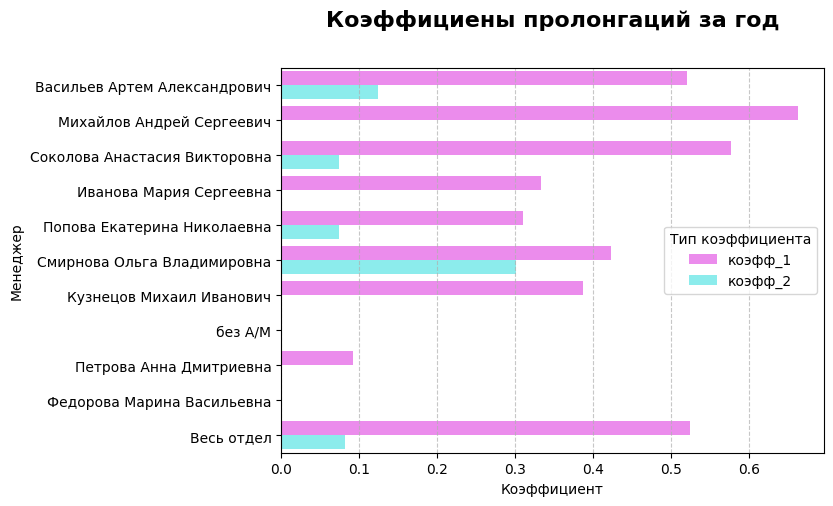

In [28]:
plt.figure(figsize=(7, 5))
sns.barplot(x='Коэффициент', y='Менеджер', hue='Тип коэфф.', data=melted_df[melted_df['Месяц'] == 'год'], errorbar=None, palette=["#fa7cfc", "#7cfcfc"])

# Заголовок и оформление
plt.title(f'Коэффициены пролонгаций за год', fontweight='bold', fontsize=16, pad=30)
plt.grid(axis='x', linestyle='--', alpha=0.7)  # Установка сетки (вертикальные линии)
plt.legend(title='Тип коэффициента')

plt.show()